### 1. Initialze初始化

In [ ]:
import os
import sys
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# 1. 挂载 Google Drive 并设置路径
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Final_Project'
IMG_DIR = f'{PROJECT_DIR}/original_data/01'
CSV_PATH = f'{PROJECT_DIR}/train.csv'

# 将项目路径加入 sys.path 以便导入自定义模块
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)


Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/Final_Project/data.zip /content/
!unzip -q /content/data.zip -d /content/local_data/

In [ ]:
!cp /content/drive/MyDrive/Final_Project/train.csv /content/

In [ ]:
import os
import pandas as pd

IMG_DIR = '/content/local_data'
CSV_PATH = '/content/train.csv'

# print("1. 正在使用 Linux 底层命令极速读取 Google Drive 文件列表...")
# # 使用 ls -U (不排序) 是读取海量文件最快的命令，将结果存入 Colab 本地硬盘
!ls -U "{IMG_DIR}" > /content/local_images.txt
!cp /content/local_images.txt /content/drive/MyDrive/Final_Project/local_images.txt

# 读取本地生成的 txt 文件，提取 ID
with open('/content/drive/MyDrive/Final_Project/local_images.txt', 'r') as f:
    # 提取所有 .jpg 文件的 ID
    existing_ids = set([line.strip().split('.')[0] for line in f.readlines() if line.strip().endswith(('.jpg', '.png'))])

print(f"-> 成功在文件夹中找到 {len(existing_ids)} 张图片！")
# 2. 从 local_images.txt 恢复真实的完整文件名映射 (防止后缀名坑)
print("正在匹配真实文件后缀...")
with open('/content/local_images.txt', 'r') as f:
    id_to_filename = {}
    for line in f.readlines():
        line = line.strip()
        if '.' in line:
            file_id = line.split('.')[0]
            id_to_filename[file_id] = line


-> 成功在文件夹中找到 100000 张图片！
正在匹配真实文件后缀...


### 2. Country -> Continent

In [ ]:
import os
import pandas as pd
from tqdm.auto import tqdm
from hash import country_to_continent

IMG_DIR = '/content/local_data/'
CSV_PATH = '/content/train.csv'

# 开启 pandas 的 tqdm 支持（用于后续的 apply 操作）
tqdm.pandas()

# ==========================================
# 1. 获取本地图片 ID
# ==========================================
print("1. 正在读取本地图片列表...")
with open('/content/local_images.txt', 'r') as f:
    existing_ids = set([line.strip().split('.')[0] for line in f.readlines() if line.strip().endswith(('.jpg', '.png'))])

print(f"-> 成功获取本地图片 ID: {len(existing_ids)} 个")
print(f"-> 本地 ID 格式示例: {list(existing_ids)[:3]}\n")

# ==========================================
# 2. 分块读取超大 CSV 并即时过滤 (核心优化)
# ==========================================
print("2. 正在分块读取并过滤 500 万行 CSV...")
chunk_size = 100000
# OSV5M 大约 500 万行，除以 10 万，大约 50 个 chunk，给 tqdm 一个 total 预估进度条
estimated_chunks = 50

filtered_chunks = []

# 使用 chunksize 迭代读取，强制 dtype=str 防止科学计数法
with pd.read_csv(CSV_PATH, dtype=str, chunksize=chunk_size, low_memory=False) as reader:
    for chunk in tqdm(reader, total=estimated_chunks, desc="CSV 过滤进度"):
        # 获取 ID 列（假设是第 1 列）
        id_col = chunk.columns[0]

        # 清理 ID：去空格、去后缀
        clean_ids = chunk[id_col].str.strip().str.replace('.jpg', '', regex=False).str.replace('.png', '', regex=False)
        chunk['id_clean'] = clean_ids

        # 即时过滤：只保留存在于 existing_ids 中的行
        valid_chunk = chunk[chunk['id_clean'].isin(existing_ids)].copy()

        # 如果这个 chunk 里有命中的数据，就保存下来
        if not valid_chunk.empty:
            # 顺便把 country 列（假设是第 2 列）也清理一下存起来
            if 'country' in valid_chunk.columns:
                valid_chunk['country_clean'] = valid_chunk['country'].astype(str).str.strip()
            else:
                raise ValueError(f"CSV 中找不到 'country' 列！实际的列名有: {valid_chunk.columns.tolist()}")

            # 只保留我们需要用到的列，极大节省内存
            filtered_chunks.append(valid_chunk[['id_clean', 'country_clean']])

# 将所有过滤后的块合并成一个小的 DataFrame
df_filtered = pd.concat(filtered_chunks, ignore_index=True)
print(f"\n-> CSV 扫描完成！成功匹配到 {len(df_filtered)} 条元数据。\n")


1. 正在读取本地图片列表...
-> 成功获取本地图片 ID: 100000 个
-> 本地 ID 格式示例: ['178435254571957', '1137756446708227', '1104366563828846']

2. 正在分块读取并过滤 500 万行 CSV...


CSV 过滤进度:   0%|          | 0/50 [00:00<?, ?it/s]


-> CSV 扫描完成！成功匹配到 100000 条元数据。



In [ ]:
# ==========================================
# 3. 映射大洲标签 (带进度条)
# ==========================================
print("3. 正在将 Country 映射为 Continent...")
# 使用 progress_apply 替代 apply，展示进度条
df_filtered['label'] = df_filtered['country_clean'].progress_apply(country_to_continent)

# 丢弃无法映射的行（比如有些奇怪的国家代码字典里没有）
df_filtered = df_filtered.dropna(subset=['label']).reset_index(drop=True)

# 为了兼容后面的 Dataset 代码，把 id_clean 列名改回 id
df_filtered = df_filtered.rename(columns={'id_clean': 'id'})

# 生成类别字典
unique_continents = sorted(df_filtered['label'].unique().tolist())
label_to_idx = {label: i for i, label in enumerate(unique_continents)}
NUM_CLASSES = len(unique_continents)

print(f"\n-> 标签映射完成！最终可用于训练的有效数据量: {len(df_filtered)}")
print(f"-> 类别数量: {NUM_CLASSES}")
print(f"-> 类别字典: {label_to_idx}")


3. 正在将 Country 映射为 Continent...


  0%|          | 0/100000 [00:00<?, ?it/s]


-> 标签映射完成！最终可用于训练的有效数据量: 99442
-> 类别数量: 10
-> 类别字典: {'East_Asia': 0, 'East_Europe_CIS': 1, 'Latin_America': 2, 'Med_MENA': 3, 'North_America': 4, 'Oceania_Islands': 5, 'South_Central_Asia': 6, 'Southeast_Asia': 7, 'Sub_Saharan_Africa': 8, 'West_North_Europe': 9}


### 3. 生成数据类

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class ContinentDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. 取出对应的行并获取真正的图片路径
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['id']}.jpg")

        # 2. 读取图片 (如果这里卡住，控制台就不会打印下一行！)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = label_to_idx[row['label']]
        return image, torch.tensor(label_idx, dtype=torch.long)


### 用transform高效crop
如果来来回回读写，将会极其低效。

In [ ]:
# 定义标准的 ResNet 预处理流水线：最短边缩放至 256 -> 中心裁剪 224x224 -> 归一化
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 实例化完整数据集
full_dataset = ContinentDataset(df_filtered, IMG_DIR, transform=transform)

NameError: name 'df_filtered' is not defined

### 把数据集切分成2部分

In [ ]:
# 计算切分大小
test_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - test_size

# 随机切分
train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42) # 固定随机种子，保证每次切分一致
)

# 构建 DataLoader (建议 num_workers=2 或 4 以加速读取)
BATCH_SIZE = 64 # 根据你的显存大小调整
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Dataset split complete: {len(train_dataset)} Train, {len(test_dataset)} Test.")


Dataset split complete: 89498 Train, 9944 Test.


### 开始训练

In [ ]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# 1. 切分出两个 Dataset Subset
train_sub_dataset, val_sub_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 2. 将它们真正包装成 DataLoader！
BATCH_SIZE = 64
train_loader = DataLoader(train_sub_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_sub_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


In [ ]:
print("正在尝试读取第一个 Batch...")
images, labels = next(iter(train_loader))
print(f"成功读取！图片形状: {images.shape}, 标签形状: {labels.shape}")


正在尝试读取第一个 Batch...
成功读取！图片形状: torch.Size([64, 3, 224, 224]), 标签形状: torch.Size([64])


In [ ]:
import os
import torch
import resnet
import loss
import train  # 🌟 导入你们自己的 train.py
import eval   # 🌟 导入你们自己的 eval.py

device = 'cuda'
print(f"Using device: {device}")

# 1. 使用你们 resnet.py 和 loss.py 中的方法初始化
model = resnet.build_resnet50(num_classes=NUM_CLASSES).to(device)
criterion = loss.build_loss()
optimizer, scheduler = resnet.build_training_components(model, learning_rate=0.001)

# 2. 开始训练
print("\n🚀 Starting training...")
history = train.train_model(  # 🌟 调用你们 train.py 里的 train_model
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=10,
    device=device
)

# 3. 评估与保存
print("\n💾 Saving model...")
save_path = os.path.join(PROJECT_DIR, 'resnet50_continent_best.pth')
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to: {save_path}")


Using device: cuda

🚀 Starting training...


Epoch 1/10:   0%|          | 0/1119 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 1.9230 | Train Acc: 32.45% | Val Loss: 1.8861 | Val Acc: 34.48%


Epoch 1/10:   0%|          | 0/1119 [00:00<?, ?it/s]

Epoch [2/10] Train Loss: 1.7412 | Train Acc: 38.24% | Val Loss: 1.6659 | Val Acc: 42.69%


...

Epoch [8/10] Train Loss: 1.1927 | Train Acc: 57.81% | Val Loss: 1.2788 | Val Acc: 55.66%


Epoch 1/10:   0%|          | 0/1119 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 1.1409 | Train Acc: 59.67% | Val Loss: 1.2579 | Val Acc: 56.62%


Epoch 1/10:   0%|          | 0/1119 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 1.0863 | Train Acc: 61.73% | Val Loss: 1.2971 | Val Acc: 55.37%

💾 Saving model...
Model successfully saved to: /content/drive/MyDrive/Final_Project/resnet50_continent_best.pth


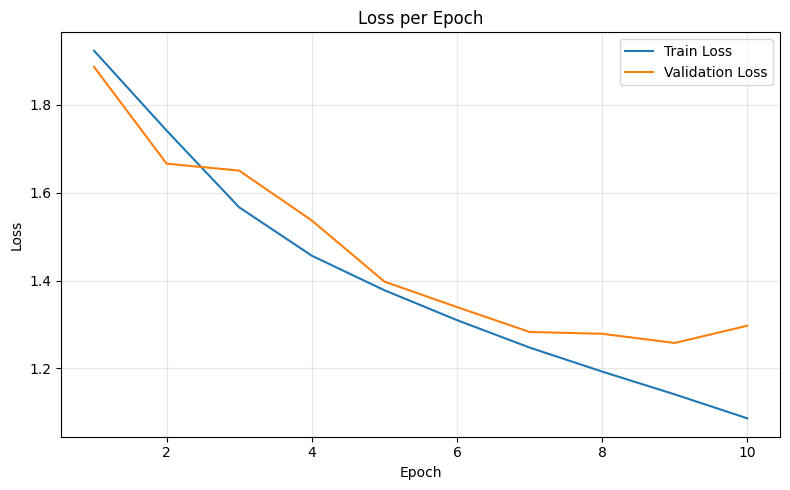

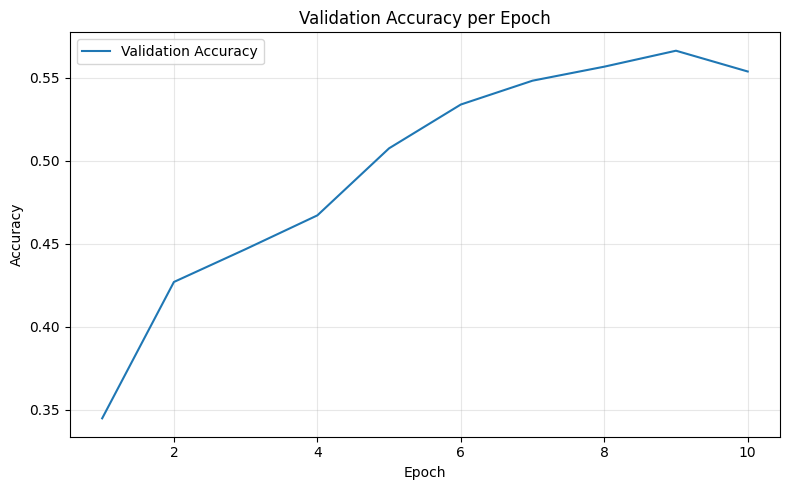

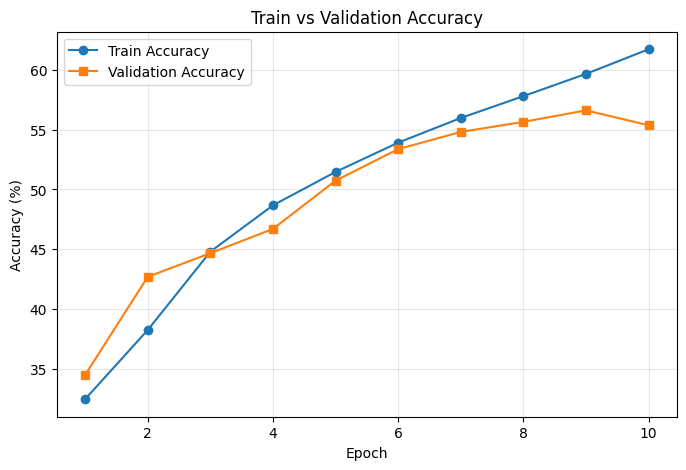

In [ ]:
import matplotlib.pyplot as plt
from visual import plot_loss, plot_acc

# 1. 绘制 Loss 曲线 (自动保存到 Google Drive)
plot_loss(
    train_loss=history["train_loss"],
    val_loss=history["val_loss"],
    save_path=f"{PROJECT_DIR}/loss_curve.png",
    show=True
)

# 2. 绘制 Validation Acc 曲线
plot_acc(
    acc=history["val_acc"],
    split_name="Validation",
    save_path=f"{PROJECT_DIR}/val_acc_curve.png",
    show=True
)

# 3. 额外补充：将 Train Acc 和 Val Acc 画在同一张图里对比
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), [x * 100 for x in history["train_acc"]], label="Train Accuracy", marker='o')
plt.plot(range(1, 11), [x * 100 for x in history["val_acc"]], label="Validation Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PROJECT_DIR}/train_val_acc_comparison.png", dpi=150)
plt.show()


In [ ]:
# Read the content of process_images.py to identify the processing function
with open('/content/drive/MyDrive/Final_Project/eval.py', 'r') as f:
    print(f.read())

import torch
import torch.nn as nn

from loss import compute_cross_entropy_loss


def _to_zero_based(labels: torch.Tensor) -> torch.Tensor:
    # ImageFolder and ContinentDataset already use 0-based indices.
    return labels.long()


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    data_loader,
    criterion: nn.Module,
    device: str = "cuda",
):
    """
    Evaluate a model on validation/test data.
    Returns a metrics dict with loss and accuracy.
    """
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
    device = torch.device(device)

    model.to(device)
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        targets = _to_zero_based(labels)

        logits = (
            model.forward_logits(images)
            if hasattr(model, "forward_logits")
            el

In [ ]:
import torch
import resnet
import os

# 1. 先用我们在前面跑通训练时的同一套代码，搭出空模型骨架
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = resnet.build_resnet50(num_classes=NUM_CLASSES).to(device)

# 2. 从存档文件中读取字典格式的权重，并塞进刚刚搭建好的骨架中
model_weights = torch.load(os.path.join(PROJECT_DIR, 'resnet50_continent_best.pth'))
model.load_state_dict(model_weights)

print("✅ 模型骨架搭建完成，且已成功注入了训练好的权重！")


✅ 模型骨架搭建完成，且已成功注入了训练好的权重！


In [ ]:
import eval
import loss
import train

# 1. 确保模型是在评估模式
print("正在评测 Testset...")
model.eval()
criterion = loss.build_loss()

# 2. 调用修改完善好的 eval 方法对 test_loader 进行评估
test_metrics = eval.evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

# 3. 打印结果
print("="*40)
print(f"🎉 Testset 评估完成！总共测试了 {test_metrics['num_samples']} 张图：")
print(f"-> Test Loss: {test_metrics['loss']:.4f}")
print(f"-> Test Accuracy: {test_metrics['acc'] * 100:.2f}%")
print("="*40)


正在评测 Testset...
🎉 Testset 评估完成！总共测试了 9944 张图：
-> Test Loss: 1.3014
-> Test Accuracy: 54.98%


-> Test Loss: 1.3014

-> Test Accuracy: 54.98%

# **Mohanet**

In [ ]:
import os
import pandas as pd
from tqdm.auto import tqdm

print("正在为 Mohanet 重新读取包含 timestamp 的独立数据...")
chunk_size = 100000
estimated_chunks = 50

filtered_chunks_temporal = []

# 重新扫一遍 CSV，这次我们把 timestamp 救回来
with pd.read_csv(CSV_PATH, dtype=str, chunksize=chunk_size, low_memory=False) as reader:
    for chunk in tqdm(reader, total=estimated_chunks, desc="提取含时间特征的元数据"):
        id_col = chunk.columns[0]

        # 清理 ID：去空格、去后缀
        clean_ids = chunk[id_col].str.strip().str.replace('.jpg', '', regex=False).str.replace('.png', '', regex=False)
        chunk['id_clean'] = clean_ids

        # 即时过滤：只保留存在于 existing_ids 中的行 (existing_ids 你在前面的 Cell 已经获取过)
        valid_chunk = chunk[chunk['id_clean'].isin(existing_ids)].copy()

        if not valid_chunk.empty:
            if 'country' in valid_chunk.columns:
                valid_chunk['country_clean'] = valid_chunk['country'].astype(str).str.strip()

            # 🌟 唯一变化：这里多保留一列 'timestamp'
            filtered_chunks_temporal.append(valid_chunk[['id_clean', 'country_clean', 'captured_at']])

# 合并并处理 Label
df_temporal = pd.concat(filtered_chunks_temporal, ignore_index=True)

print("正在映射大洲标签...")
df_temporal['label'] = df_temporal['country_clean'].progress_apply(country_to_continent)
df_temporal = df_temporal.dropna(subset=['label']).reset_index(drop=True)

# 保持与你原有代码相同的列名习惯
df_temporal = df_temporal.rename(columns={'id_clean': 'id'})

print(f"-> 专属带时间戳的数据准备完毕，共 {len(df_temporal)} 条！")

正在为 Mohanet 重新读取包含 timestamp 的独立数据...


提取含时间特征的元数据:   0%|          | 0/50 [00:00<?, ?it/s]

正在映射大洲标签...


  0%|          | 0/100000 [00:00<?, ?it/s]

-> 专属带时间戳的数据准备完毕，共 99442 条！


In [ ]:
import temporal
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split

class TemporalContinentDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. 图像
        img_path = os.path.join(self.img_dir, f"{row['id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # 2. 🌟 时间特征
        time_tensor = temporal.encode_timestamp(int(row['captured_at']))

        # 3. 标签 (label_to_idx 字典在你的 Cell 7 已经生成好了，直接用)
        label_idx = label_to_idx[row['label']]
        label_tensor = torch.tensor(label_idx, dtype=torch.long)

        return image, time_tensor, label_tensor

In [ ]:
# 实例化完整的专属数据集 (transform 在你原来的 Cell 11 已经定义好了，直接用)
temporal_full_dataset = TemporalContinentDataset(df_temporal, IMG_DIR, transform=transform)

# 完全照搬你的切分大小算法
test_size = int(0.1 * len(temporal_full_dataset))
train_size = len(temporal_full_dataset) - test_size

# 按照与原来一模一样的随机种子进行切分
temporal_train_dataset, temporal_test_dataset = random_split(
    temporal_full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 构建带有时间流的专属 DataLoader
BATCH_SIZE = 64
temporal_train_loader = DataLoader(temporal_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
temporal_test_loader = DataLoader(temporal_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Dataset split complete: {len(temporal_train_dataset)} Train, {len(temporal_test_dataset)} Test.")

# 测试一下能不能吐出带时间的 Batch
images, times, labels = next(iter(temporal_train_loader))
print(f"完美运行！当前 Batch -> Image: {images.shape}, Time: {times.shape}, Label: {labels.shape}")

Dataset split complete: 89498 Train, 9944 Test.
完美运行！当前 Batch -> Image: torch.Size([64, 3, 224, 224]), Time: torch.Size([64, 4]), Label: torch.Size([64])


In [ ]:
import mohanet

# 1. 实例化Mohanet
model = mohanet.build_mohanet(num_classes=10, time_feature_dim=4)

# 2. 加载之前存好的 Baseline 权重
save_path = os.path.join(PROJECT_DIR, 'resnet50_continent_best.pth')

print(f"Loading pretrained weights from {save_path}...")
checkpoint = torch.load(save_path)

# 3. 过滤掉旧模型中名为 'fc' 的权重（因为新模型里叫 fusion_classifier）
pretrained_dict = {
    k: v for k, v in checkpoint.items()
    if not k.startswith("fc.")
}

# 4. 将旧的 CNN 权重灌入 Mohanet（strict=False 允许 fusion_classifier 保持随机初始化）
missing_keys, unexpected_keys = model.load_state_dict(pretrained_dict, strict=False)
print("Successfully loaded CNN backbone weights!")
# 你可以打印 missing_keys 看看，应该只有 fusion_classifier 相关的层是 missing 的，这是正常的。

model = model.cuda() # 别忘了放进 A100 里

Loading pretrained weights from /content/drive/MyDrive/Final_Project/resnet50_continent_best.pth...
Successfully loaded CNN backbone weights!


In [ ]:
# 1. 冻结模型中的所有参数
for param in model.parameters():
    param.requires_grad = False

# 2. 解冻 (Unfreeze) fusion_classifier 中的所有参数
for param in model.fusion_classifier.parameters():
    param.requires_grad = True

# 验证一下：打印可训练参数数量
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# 3. 重新构造 Optimizer，并!!只把需要求梯度的参数!!传进去
import torch.optim as optim
import torch.nn as nn

# 过滤出 requires_grad=True 的参数给 Adam
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()


Total parameters: 24,565,322
Trainable parameters: 1,057,290


In [ ]:
from tqdm.notebook import tqdm

EPOCHS = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # 使用 tqdm 包装 temporal_train_loader 显示进度条
    pbar = tqdm(temporal_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, times, labels in pbar:
        # 将数据移入 GPU
        images = images.to(device)
        times = times.to(device)
        labels = labels.to(device)

        # 清空梯度
        optimizer.zero_grad()

        # ⚠️ 关键点：使用 forward_logits 获取没经过 softmax 的原始分数，用于接下来的交叉熵损失计算
        logits = model.forward_logits(images, times)

        # 计算 Loss
        loss = criterion(logits, labels)

        # 反向传播 & 参数更新（这时因为冻结了，所以只有 fusion_classifier 更新）
        loss.backward()
        optimizer.step()

        # 统计结果
        running_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 更新进度条后面的显示
        pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100. * correct / total:.2f}%"})

    epoch_loss = running_loss / len(temporal_train_loader)
    epoch_acc = 100. * correct / total

    # ---------------- 验证集阶段 (Validation) ----------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # 验证阶段不需要计算梯度
    with torch.no_grad():
        val_pbar = tqdm(temporal_test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for images, times, labels in val_pbar:
            images = images.to(device)
            times = times.to(device)
            labels = labels.to(device)

            logits = model.forward_logits(images, times)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100. * val_correct / val_total:.2f}%"})

    val_loss /= len(temporal_test_loader)
    val_acc = 100. * val_correct / val_total

    print(f"⭐ Epoch {epoch+1} Summary | Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # 根据验证集的 loss 更新学习率（Learning Rate Scheduling）
    scheduler.step(val_loss)

# 全部训练结束后，不要忘记把模型权重保存下来
torch.save(model.state_dict(), 'mohanet_temporal_best.pth')
print("Model saved to mohanet_temporal_best.pth")


Epoch 1/5 [Train]:   0%|          | 0/1399 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/156 [00:00<?, ?it/s]

⭐ Epoch 1 Summary | Train Loss: 0.9501, Train Acc: 66.68% | Val Loss: 1.0420, Val Acc: 63.13%


Epoch 2/5 [Train]:   0%|          | 0/1399 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/156 [00:00<?, ?it/s]

⭐ Epoch 4 Summary | Train Loss: 0.8572, Train Acc: 69.52% | Val Loss: 0.9891, Val Acc: 65.15%


Epoch 5/5 [Train]:   0%|          | 0/1399 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/156 [00:00<?, ?it/s]

⭐ Epoch 5 Summary | Train Loss: 0.8464, Train Acc: 69.91% | Val Loss: 0.9803, Val Acc: 65.35%
Model saved to mohanet_temporal_best.pth


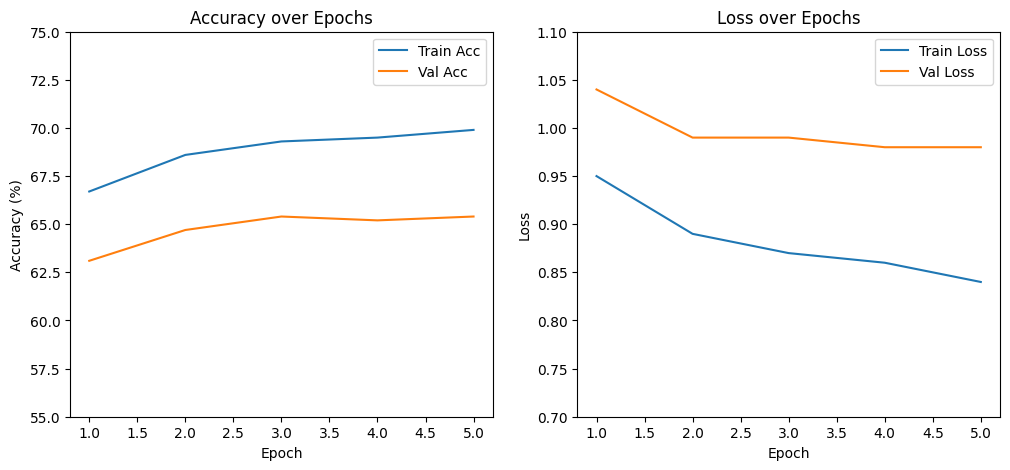

In [ ]:
import matplotlib.pyplot as plt

train_acc = [66.7, 68.6, 69.3, 69.5, 69.9]
val_acc = [63.1, 64.7, 65.4, 65.2, 65.4]
train_loss = [0.95, 0.89, 0.87, 0.86, 0.84]
val_loss = [1.04, 0.99, 0.99, 0.98, 0.98]
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylim(55, 75)
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.7, 1.1)
plt.legend()

plt.show()


In [ ]:
# 3. 评估与保存
print("\n💾 Saving model...")
save_path = os.path.join(PROJECT_DIR, 'mohanet_temporal_best.pth')
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to: {save_path}")



💾 Saving model...
Model successfully saved to: /content/drive/MyDrive/Final_Project/mohanet_temporal_best.pth


In [ ]:
import torch
import resnet
import os

# 1. 先用我们在前面跑通训练时的同一套代码，搭出空模型骨架
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = resnet.build_resnet50(num_classes=NUM_CLASSES).to(device)

# 2. 从存档文件中读取字典格式的权重，并塞进刚刚搭建好的骨架中
model_weights = torch.load(os.path.join(PROJECT_DIR, 'mohanet_temporal_best.pth'))
model.load_state_dict(model_weights)

print("✅ 模型骨架搭建完成，且已成功注入了训练好的权重！")


✅ 模型骨架搭建完成，且已成功注入了训练好的权重！


In [ ]:
import mohanet
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 搭建 Mohanet 的骨架 (!!必须是 Mohanet, 不是 ResNet50!!)
model_test = mohanet.build_mohanet(num_classes=10, time_feature_dim=4).to(device)

# 2. 注入刚刚训练好的最佳权重
model_test.load_state_dict(torch.load('mohanet_temporal_best.pth'))
print("✅ Mohanet 模型骨架搭建完成，权重注入成功！")

# 3. 开始专属 Test 循环
model_test.eval()
criterion = torch.nn.CrossEntropyLoss()
test_loss = 0.0
correct = 0
total = 0

print("正在评测 Testset...")
with torch.no_grad():
    # ⚠️ 必须用 temporal_test_loader
    for images, times, labels in temporal_test_loader:
        images = images.to(device)
        times = times.to(device)       # ⚠️ 这个非常重要，得把时间送进 GPU
        labels = labels.to(device)

        # ⚠️ 必须调用 forward_logits 才能获得没经过 Softmax 的原始数值算交叉熵
        logits = model_test.forward_logits(images, times)
        loss = criterion(logits, labels)

        test_loss += loss.item()

        # 取最大概率的索引即为大洲预测结果
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_loss = test_loss / len(temporal_test_loader)
avg_acc = 100. * correct / total

print("="*40)
print(f"🎉 Temporal Testset 评估完成！总共测试了 {total} 张图：")
print(f"-> Test Loss: {avg_loss:.4f}")
print(f"-> Test Accuracy: {avg_acc:.2f}%")
print("="*40)


✅ Mohanet 模型骨架搭建完成，权重注入成功！
正在评测 Testset...
🎉 Temporal Testset 评估完成！总共测试了 9944 张图：
-> Test Loss: 0.9803
-> Test Accuracy: 65.35%


-> Test Loss: 0.9803

-> Test Accuracy: 65.35%

## Ablation Study


In [ ]:
import os
import copy
import hashlib
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm
from IPython.display import display

import mohanet

assert 'PROJECT_DIR' in globals()
assert 'IMG_DIR' in globals()
assert 'transform' in globals()
assert 'label_to_idx' in globals()
assert 'NUM_CLASSES' in globals()
assert 'df_temporal' in globals(), "Please run the temporal-data preparation cell first."

ARTIFICIAL_FEATURE_DIM = 4          # match temporal feature dim
ARTIFICIAL_BATCH_SIZE = 64
ARTIFICIAL_EPOCHS = 5
ARTIFICIAL_LR = 1e-3
ARTIFICIAL_WEIGHT_DECAY = 1e-5
ARTIFICIAL_SEED = 42

ARTIFICIAL_RESNET_CKPT = os.path.join(PROJECT_DIR, 'resnet50_continent_best.pth')
ARTIFICIAL_MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_best.pth')
ARTIFICIAL_HISTORY_PT_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_history.pt')
ARTIFICIAL_HISTORY_CSV_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_history.csv')
ARTIFICIAL_TEST_METRICS_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_test_metrics.pt')
ARTIFICIAL_CURVE_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_curves.png')

torch.manual_seed(ARTIFICIAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(ARTIFICIAL_SEED)

artificial_df = df_temporal.copy()
print(f"Using df_temporal as the sample pool: {len(artificial_df)} samples")
print(f"ResNet checkpoint path: {ARTIFICIAL_RESNET_CKPT}")


Using df_temporal as the sample pool: 99442 samples
ResNet checkpoint path: /content/drive/MyDrive/Final_Project/resnet50_continent_best.pth


In [ ]:
def deterministic_artificial_feature(sample_id, feature_dim=4, seed=42):
    """
    Give each sample a fixed random-like feature vector.
    Important: fixed per sample, not re-sampled every epoch.
    """
    digest = hashlib.sha256(f"{sample_id}_{seed}".encode("utf-8")).digest()

    values = []
    for i in range(feature_dim):
        start = i * 4
        integer = int.from_bytes(digest[start:start + 4], "big", signed=False)
        value = (integer / 4294967295.0) * 2.0 - 1.0   # scale to [-1, 1]
        values.append(value)

    return torch.tensor(values, dtype=torch.float32)


class ArtificialContinentDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, feature_dim=4, seed=42, id_to_filename=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.feature_dim = feature_dim
        self.seed = seed
        self.id_to_filename = id_to_filename or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row['id'])

        filename = self.id_to_filename.get(sample_id, f"{sample_id}.jpg")
        img_path = os.path.join(self.img_dir, filename)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        artificial_tensor = deterministic_artificial_feature(
            sample_id=sample_id,
            feature_dim=self.feature_dim,
            seed=self.seed
        )

        label_idx = label_to_idx[row['label']]
        label_tensor = torch.tensor(label_idx, dtype=torch.long)

        return image, artificial_tensor, label_tensor


filename_map = {str(k): v for k, v in id_to_filename.items()} if 'id_to_filename' in globals() else {}

artificial_full_dataset = ArtificialContinentDataset(
    dataframe=artificial_df,
    img_dir=IMG_DIR,
    transform=transform,
    feature_dim=ARTIFICIAL_FEATURE_DIM,
    seed=ARTIFICIAL_SEED,
    id_to_filename=filename_map
)

print(f"Artificial full dataset ready: {len(artificial_full_dataset)} samples")


Artificial full dataset ready: 99442 samples


In [ ]:
# Keep the same 10% final test split idea as before,
# but carve validation from the training portion so test stays clean.

test_size = int(0.1 * len(artificial_full_dataset))
train_size = len(artificial_full_dataset) - test_size

artificial_train_dataset, artificial_test_dataset = random_split(
    artificial_full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(ARTIFICIAL_SEED)
)

train_sub_size = int(0.8 * len(artificial_train_dataset))
val_sub_size = len(artificial_train_dataset) - train_sub_size

artificial_train_sub_dataset, artificial_val_sub_dataset = random_split(
    artificial_train_dataset,
    [train_sub_size, val_sub_size],
    generator=torch.Generator().manual_seed(ARTIFICIAL_SEED)
)

artificial_train_loader = DataLoader(
    artificial_train_sub_dataset,
    batch_size=ARTIFICIAL_BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

artificial_val_loader = DataLoader(
    artificial_val_sub_dataset,
    batch_size=ARTIFICIAL_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

artificial_test_loader = DataLoader(
    artificial_test_dataset,
    batch_size=ARTIFICIAL_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train: {len(artificial_train_sub_dataset)}")
print(f"Val:   {len(artificial_val_sub_dataset)}")
print(f"Test:  {len(artificial_test_dataset)}")

images, artificial_features, labels = next(iter(artificial_train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Artificial feature batch shape: {artificial_features.shape}")
print(f"Label batch shape: {labels.shape}")
print("Example artificial feature:", artificial_features[0])


Train: 71598
Val:   17900
Test:  9944


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Image batch shape: torch.Size([64, 3, 224, 224])
Artificial feature batch shape: torch.Size([64, 4])
Label batch shape: torch.Size([64])
Example artificial feature: tensor([ 0.7861,  0.9218, -0.3286, -0.7539])


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_artificial = mohanet.build_mohanet(
    num_classes=NUM_CLASSES,
    time_feature_dim=ARTIFICIAL_FEATURE_DIM
).to(device)

checkpoint = torch.load(ARTIFICIAL_RESNET_CKPT, map_location=device)

# Load only the ResNet backbone weights, skip old fc layer
pretrained_dict = {
    k: v for k, v in checkpoint.items()
    if not k.startswith("fc.")
}

load_result = model_artificial.load_state_dict(pretrained_dict, strict=False)
print(load_result)

# Freeze backbone, train only the fusion MLP head
for param in model_artificial.parameters():
    param.requires_grad = False

for param in model_artificial.fusion_classifier.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model_artificial.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_artificial.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_artificial.parameters()),
    lr=ARTIFICIAL_LR,
    weight_decay=ARTIFICIAL_WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

criterion = nn.CrossEntropyLoss()


Using device: cuda
_IncompatibleKeys(missing_keys=['fusion_classifier.0.weight', 'fusion_classifier.0.bias', 'fusion_classifier.1.weight', 'fusion_classifier.1.bias', 'fusion_classifier.1.running_mean', 'fusion_classifier.1.running_var', 'fusion_classifier.3.weight', 'fusion_classifier.3.bias'], unexpected_keys=[])
Total parameters: 24,565,322
Trainable parameters: 1,057,290


In [ ]:
history_artificial = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
}

best_val_acc = -1.0
best_state_dict = None

for epoch in range(ARTIFICIAL_EPOCHS):
    # ---------------- Train ----------------
    model_artificial.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(artificial_train_loader, desc=f"Epoch {epoch+1}/{ARTIFICIAL_EPOCHS} [Train]")

    for images, artificial_features, labels in train_pbar:
        images = images.to(device, non_blocking=True)
        artificial_features = artificial_features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model_artificial.forward_logits(images, artificial_features)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        train_loss_sum += loss.item() * batch_size

        _, predicted = torch.max(logits, 1)
        train_total += batch_size
        train_correct += (predicted == labels).sum().item()

        train_pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{100.0 * train_correct / train_total:.2f}%"
        })

    train_epoch_loss = train_loss_sum / train_total
    train_epoch_acc = train_correct / train_total

    # ---------------- Validation ----------------
    model_artificial.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        val_pbar = tqdm(artificial_val_loader, desc=f"Epoch {epoch+1}/{ARTIFICIAL_EPOCHS} [Val]")
        for images, artificial_features, labels in val_pbar:
            images = images.to(device, non_blocking=True)
            artificial_features = artificial_features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model_artificial.forward_logits(images, artificial_features)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            val_loss_sum += loss.item() * batch_size

            _, predicted = torch.max(logits, 1)
            val_total += batch_size
            val_correct += (predicted == labels).sum().item()

            val_pbar.set_postfix({
                "Loss": f"{loss.item():.4f}",
                "Acc": f"{100.0 * val_correct / val_total:.2f}%"
            })

    val_epoch_loss = val_loss_sum / val_total
    val_epoch_acc = val_correct / val_total

    scheduler.step(val_epoch_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history_artificial["epoch"].append(epoch + 1)
    history_artificial["train_loss"].append(train_epoch_loss)
    history_artificial["train_acc"].append(train_epoch_acc)
    history_artificial["val_loss"].append(val_epoch_loss)
    history_artificial["val_acc"].append(val_epoch_acc)
    history_artificial["lr"].append(current_lr)

    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        best_state_dict = copy.deepcopy(model_artificial.state_dict())
        torch.save(best_state_dict, ARTIFICIAL_MODEL_SAVE_PATH)
        print(f"Saved new best model to: {ARTIFICIAL_MODEL_SAVE_PATH}")

    pd.DataFrame(history_artificial).to_csv(ARTIFICIAL_HISTORY_CSV_PATH, index=False)
    torch.save(history_artificial, ARTIFICIAL_HISTORY_PT_PATH)

    print(
        f"Epoch {epoch+1} Summary | "
        f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_acc * 100:.2f}% | "
        f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

if best_state_dict is not None:
    model_artificial.load_state_dict(best_state_dict)

print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")
print(f"History saved to: {ARTIFICIAL_HISTORY_CSV_PATH}")


Epoch 1/5 [Train]:   0%|          | 0/1118 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/280 [00:00<?, ?it/s]

Saved new best model to: /content/drive/MyDrive/Final_Project/mohanet_artificial_best.pth
Epoch 1 Summary | Train Loss: 1.0058, Train Acc: 64.52% | Val Loss: 1.1800, Val Acc: 59.98% | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/1118 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/280 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/280 [00:00<?, ?it/s]

Epoch 4 Summary | Train Loss: 0.9348, Train Acc: 66.95% | Val Loss: 1.1755, Val Acc: 59.77% | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/1118 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/280 [00:00<?, ?it/s]

Epoch 5 Summary | Train Loss: 0.9293, Train Acc: 67.16% | Val Loss: 1.1601, Val Acc: 60.39% | LR: 0.001000
Best validation accuracy: 60.57%
History saved to: /content/drive/MyDrive/Final_Project/mohanet_artificial_history.csv


,epoch,train_loss,train_acc,val_loss,val_acc,lr
0,1,1.005769,0.645167,1.180013,0.599777,0.001
1,2,0.962890,0.660638,1.178878,0.595698,0.001
2,3,0.946479,0.666816,1.146532,0.605698,0.001
3,4,0.934815,0.669541,1.175521,0.597654,0.001
4,5,0.929346,0.671568,1.160053,0.603855,0.001


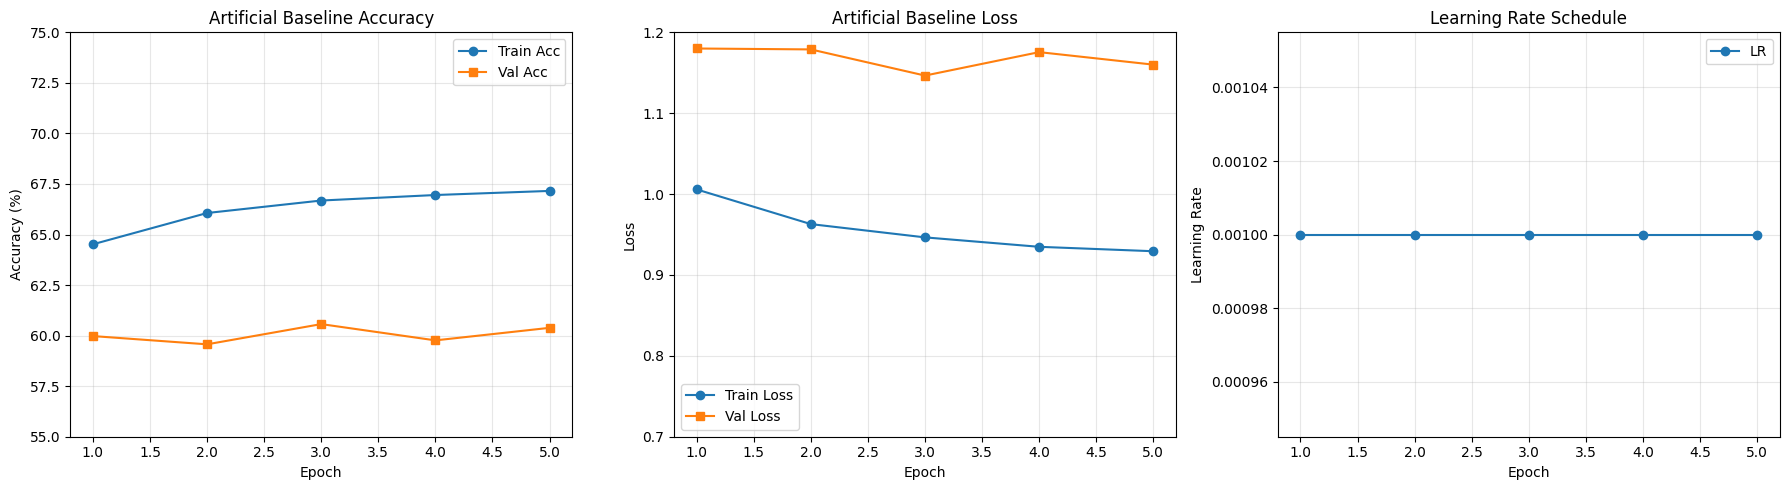

Curves saved to: /content/drive/MyDrive/Final_Project/mohanet_artificial_curves.png


In [ ]:
history_df = pd.DataFrame(history_artificial)
display(history_df)

plt.figure(figsize=(18, 5))

# Loss
plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["train_loss"], marker='o', label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker='s', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim(0.7, 1.2)
plt.title("Artificial Baseline Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_acc"] * 100, marker='o', label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"] * 100, marker='s', label="Val Acc")
plt.xlabel("Epoch")
plt.ylim(55, 75)
plt.ylabel("Accuracy (%)")
plt.title("Artificial Baseline Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

# Learning Rate
plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["lr"], marker='o', label="LR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(ARTIFICIAL_CURVE_PATH, dpi=150)
plt.show()

print(f"Curves saved to: {ARTIFICIAL_CURVE_PATH}")


In [ ]:
import os
import torch
import mohanet
from tqdm.notebook import tqdm

assert 'NUM_CLASSES' in globals()
assert 'ARTIFICIAL_FEATURE_DIM' in globals()
assert 'ARTIFICIAL_MODEL_SAVE_PATH' in globals()
assert 'artificial_test_loader' in globals(), "Please run the artificial split cell first."
assert 'PROJECT_DIR' in globals()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss()

# 1. 搭建 Artificial Mohanet 骨架
model_artificial_test = mohanet.build_mohanet(
    num_classes=NUM_CLASSES,
    time_feature_dim=ARTIFICIAL_FEATURE_DIM
).to(device)

# 2. 注入训练好的最佳权重
model_artificial_test.load_state_dict(
    torch.load(ARTIFICIAL_MODEL_SAVE_PATH, map_location=device)
)
print("Artificial Mohanet loaded successfully!")

# 3. 开始测试
model_artificial_test.eval()
test_loss_sum = 0.0
correct = 0
total = 0

print("Evaluating artificial-feature baseline on test set...")

with torch.no_grad():
    test_pbar = tqdm(artificial_test_loader, desc="Artificial Test")
    for images, artificial_features, labels in test_pbar:
        images = images.to(device, non_blocking=True)
        artificial_features = artificial_features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model_artificial_test.forward_logits(images, artificial_features)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        test_loss_sum += loss.item() * batch_size

        _, predicted = torch.max(logits, 1)
        total += batch_size
        correct += (predicted == labels).sum().item()

        test_pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{100.0 * correct / total:.2f}%"
        })

artificial_test_metrics = {
    "loss": test_loss_sum / total,
    "acc": correct / total,
    "num_samples": total
}

ARTIFICIAL_TEST_METRICS_PATH = os.path.join(PROJECT_DIR, 'mohanet_artificial_test_metrics.pt')
torch.save(artificial_test_metrics, ARTIFICIAL_TEST_METRICS_PATH)

print("=" * 50)
print(f"Artificial Test Loss: {artificial_test_metrics['loss']:.4f}")
print(f"Artificial Test Accuracy: {artificial_test_metrics['acc'] * 100:.2f}%")
print(f"Num Samples: {artificial_test_metrics['num_samples']}")
print("=" * 50)
print(f"Test metrics saved to: {ARTIFICIAL_TEST_METRICS_PATH}")


Artificial Mohanet loaded successfully!
Evaluating artificial-feature baseline on test set...


Artificial Test:   0%|          | 0/156 [00:00<?, ?it/s]

Artificial Test Loss: 1.1375
Artificial Test Accuracy: 60.36%
Num Samples: 9944
Test metrics saved to: /content/drive/MyDrive/Final_Project/mohanet_artificial_test_metrics.pt


-> Test Loss: 1.1375

-> Test Accuracy: 60.36%